# ID3: diagnosing small leaves and choosing a stopping rule

The course implementation in notebook 02 is adapted from the course lab and Peter Harrington's
*Machine Learning in Action*, chapter 3. This follow-up records rows per leaf and adds a minimum-leaf rule.

An earlier version chose this rule using test scores. Here the original training partition is split again:
diagnosis and selection use validation rows, followed by one final test comparison. The same dataset and
outer test split were previously explored, so this is not a fresh independent benchmark.


In [1]:
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv('car.data', header=None, names=columns)
shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
cut = int(len(df) * 0.8)
outer_train, test = shuffled.iloc[:cut].copy(), shuffled.iloc[cut:].copy()
train, validation = train_test_split(outer_train, test_size=0.2, stratify=outer_train['class'], random_state=42)
attributes = columns[:-1]
values = {a: sorted(train[a].unique()) for a in attributes}
assert set(train.index).isdisjoint(validation.index)
assert set(outer_train.index).isdisjoint(test.index)
print('Inner training:', len(train), '| validation:', len(validation), '| test:', len(test))


Inner training: 1105 | validation: 277 | test: 346


In [2]:
import math

def entropy(labels):
    """Shannon entropy of a list/Series of class labels."""
    n = len(labels)
    if n == 0:
        return 0.0
    counts = labels.value_counts()
    ent = 0.0
    for count in counts:
        p = count / n
        ent -= p * math.log2(p)
    return ent


def information_gain(data, attribute, target_col):
    """Information gain from splitting `data` on `attribute`."""
    base_entropy = entropy(data[target_col])
    n = len(data)
    weighted_entropy = 0.0
    for value, subset in data.groupby(attribute):
        weighted_entropy += (len(subset) / n) * entropy(subset[target_col])
    return base_entropy - weighted_entropy


def best_attribute(data, attributes, target_col):
    """Return the attribute (from `attributes`) with the highest information gain."""
    gains = {attr: information_gain(data, attr, target_col) for attr in attributes}
    return max(gains, key=gains.get)


def majority_class(data, target_col):
    """Return the most frequent class label."""
    return data[target_col].value_counts().idxmax()

class Leaf:
    """A leaf, plus how many training rows it was built from."""
    def __init__(self, label, n_rows):
        self.label = label
        self.n_rows = n_rows

def build_tree(data, attributes, target_col, attribute_values, min_samples_leaf=1):
    """
    ID3 tree induction.
    `min_samples_leaf` is the only addition to the version in notebook 02: a split is allowed
    only if every branch it creates has at least this many training rows behind it. At 1 the
    rule never fires and the tree is exactly the one from notebook 02.
    """
    if data[target_col].nunique() == 1:
        return Leaf(data[target_col].iloc[0], len(data))
    if len(attributes) == 0:
        return Leaf(majority_class(data, target_col), len(data))

    # attributes whose split leaves every non-empty branch thick enough
    allowed = []
    for attr in attributes:
        sizes = [len(data[data[attr] == v]) for v in attribute_values[attr]]
        if all(s == 0 or s >= min_samples_leaf for s in sizes):
            allowed.append(attr)

    if not allowed:
        return Leaf(majority_class(data, target_col), len(data))

    attr = best_attribute(data, allowed, target_col)
    remaining_attributes = [a for a in attributes if a != attr]

    tree = {attr: {}}
    parent_majority = majority_class(data, target_col)

    for value in attribute_values[attr]:
        subset = data[data[attr] == value]
        if len(subset) == 0:
            tree[attr][value] = Leaf(parent_majority, 0)
        else:
            tree[attr][value] = build_tree(subset, remaining_attributes, target_col,
                                           attribute_values, min_samples_leaf)
    return tree
def classify(tree, sample):
    """Walk one row from the root to a leaf. Returns (predicted label, rows behind that leaf)."""
    if isinstance(tree, Leaf):
        return tree.label, tree.n_rows
    attr = next(iter(tree))
    return classify(tree[attr][sample[attr]], sample)

def leaf_sizes(tree, out):
    if isinstance(tree, Leaf):
        out.append(tree.n_rows)
        return
    attr = next(iter(tree))
    for sub in tree[attr].values():
        leaf_sizes(sub, out)

def tree_depth(tree):
    if isinstance(tree, Leaf):
        return 0
    attr = next(iter(tree))
    return 1 + max(tree_depth(sub) for sub in tree[attr].values())


## Validation errors by leaf support

Zero-row branches return the parent majority class. Support is one diagnostic: large leaves can also
represent easier regions. Comparing the buckets alone cannot prove that small leaves cause every error.


In [3]:
base_tree = build_tree(train, attributes, 'class', values)
records = []
for _, row in validation.iterrows():
    label, support = classify(base_tree, row)
    records.append({'support': support, 'correct': label == row['class']})
errors = pd.DataFrame(records)
errors['bucket'] = pd.cut(errors.support, [-1, 0, 1, 2, 4, 8, np.inf], labels=['0', '1', '2', '3-4', '5-8', '9+'])
by_bucket = errors.groupby('bucket', observed=True).correct.agg(['size', 'sum', 'mean'])
by_bucket['wrong'] = by_bucket['size'] - by_bucket['sum']
display(by_bucket.round(3))


,size,sum,mean,wrong
bucket,,,,
0,14,4,0.286,10
1,30,20,0.667,10
2,23,18,0.783,5
3-4,10,10,1.000,0
5-8,31,29,0.935,2
9+,169,169,1.000,0


## Select a leaf threshold on validation

The five candidate thresholds are fixed before this run. The same values are checked for the library tree,
but a binary split and a multi-way split face different constraints. This is not a like-for-like complexity budget.


In [4]:
X_train = pd.get_dummies(train[attributes])
X_val = pd.get_dummies(validation[attributes]).reindex(columns=X_train.columns, fill_value=0)
rows = []
for threshold in [1, 2, 3, 5, 10]:
    tree = build_tree(train, attributes, 'class', values, min_samples_leaf=threshold)
    score = (validation.apply(lambda row: classify(tree, row)[0], axis=1) == validation['class']).mean()
    sk = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=threshold, random_state=42).fit(X_train, train['class'])
    rows.append({'min_samples_leaf': threshold, 'id3_validation': score,
                 'sklearn_validation': sk.score(X_val, validation['class'])})
validation_results = pd.DataFrame(rows).set_index('min_samples_leaf')
display(validation_results.round(4))
chosen_id3 = int(validation_results.id3_validation.idxmax())
chosen_sk = int(validation_results.sklearn_validation.idxmax())
print('Selected thresholds:', chosen_id3, '(ID3),', chosen_sk, '(sklearn)')


,id3_validation,sklearn_validation
min_samples_leaf,,
1,0.9025,0.9819
2,0.8881,0.9458
3,0.8736,0.9314
5,0.8556,0.9314
10,0.8448,0.9134


Selected thresholds: 1 (ID3), 1 (sklearn)


## Refit and evaluate

Refit on all original training rows. Report the original ID3 rule, the validation-selected ID3 rule and
the validation-selected library tree. Test scores do not change the selected thresholds.


In [5]:
outer_values = {a: sorted(outer_train[a].unique()) for a in attributes}
final_rows = []
for name, threshold in [('ID3 baseline', 1), ('ID3 validation-selected', chosen_id3)]:
    tree = build_tree(outer_train, attributes, 'class', outer_values, min_samples_leaf=threshold)
    test_accuracy = (test.apply(lambda row: classify(tree, row)[0], axis=1) == test['class']).mean()
    final_rows.append({'model': name, 'min_samples_leaf': threshold, 'test_accuracy': test_accuracy})
X_outer = pd.get_dummies(outer_train[attributes])
X_test = pd.get_dummies(test[attributes]).reindex(columns=X_outer.columns, fill_value=0)
sk = DecisionTreeClassifier(criterion='entropy', min_samples_leaf=chosen_sk, random_state=42).fit(X_outer, outer_train['class'])
final_rows.append({'model': 'sklearn validation-selected', 'min_samples_leaf': chosen_sk,
                   'test_accuracy': sk.score(X_test, test['class'])})
final_results = pd.DataFrame(final_rows)
display(final_results.round(4))
final_results.to_csv('comparison_results.csv', index=False)
validation_results.to_csv('validation_results.csv')


,model,min_samples_leaf,test_accuracy
0,ID3 baseline,1,0.8757
1,ID3 validation-selected,1,0.8757
2,sklearn validation-selected,1,0.9740


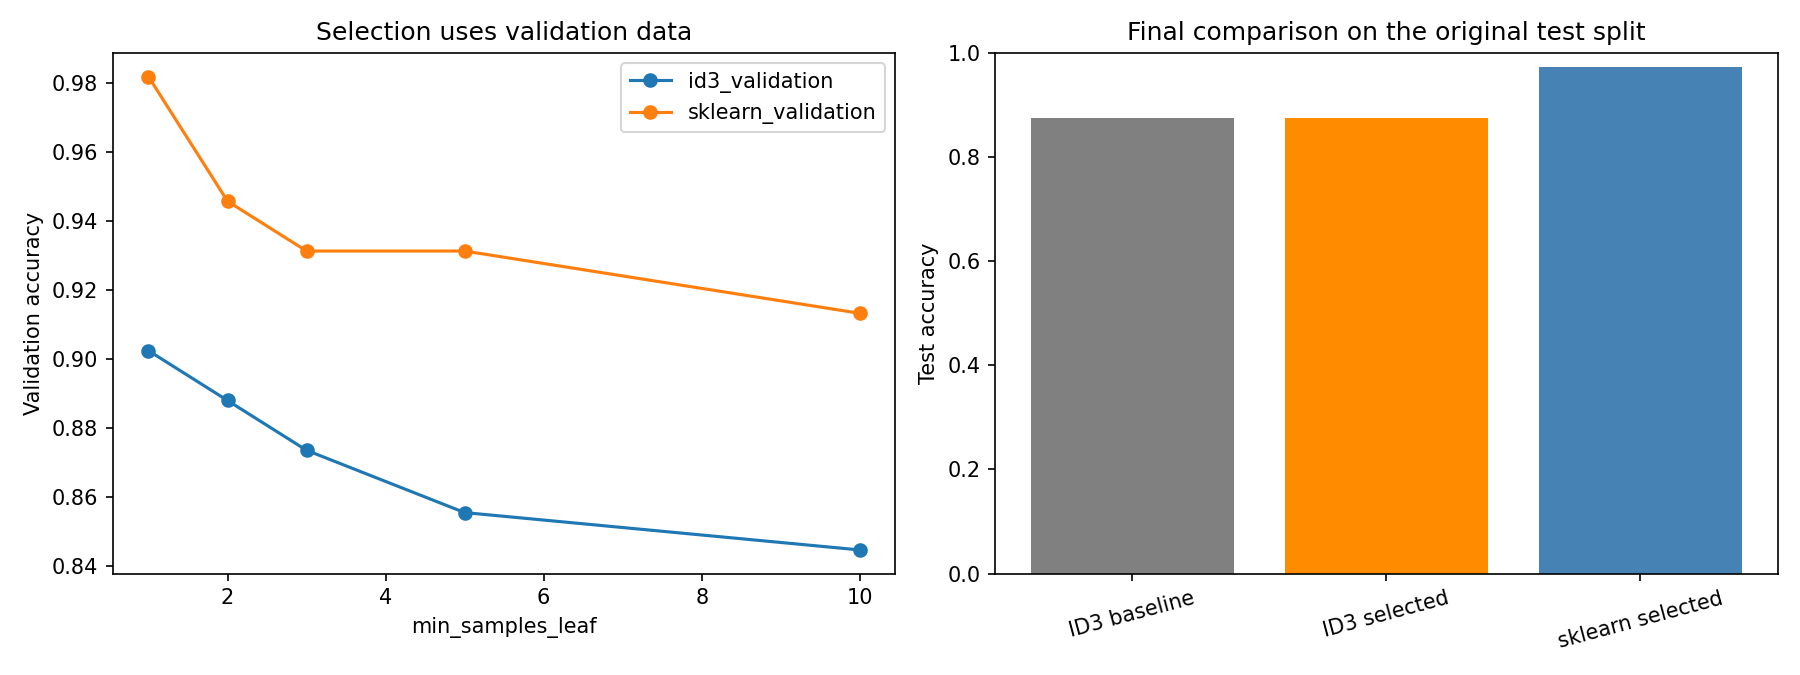

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
validation_results.plot(marker='o', ax=axes[0])
axes[0].set(title='Selection uses validation data', ylabel='Validation accuracy')
axes[1].bar(['ID3 baseline', 'ID3 selected', 'sklearn selected'], final_results.test_accuracy, color=['grey', 'darkorange', 'steelblue'])
axes[1].set(title='Final comparison on the original test split', ylabel='Test accuracy', ylim=(0, 1))
axes[1].tick_params(axis='x', labelrotation=15)
fig.tight_layout()
fig.savefig('images/id3_vs_sklearn.png', dpi=150)
plt.show()


## What this experiment supports

The validation sweep checks whether restricting small leaves helps this implementation on this split.
Changing the threshold also changes which attributes can split, so it does not isolate one cause of the
gap to the library model. The library exposes tree structure and leaf counts too; the learning value here
is implementing the rule and inspecting its consequences directly.

Limits: one small categorical dataset, one split, no pruning, and a historically reused test partition.
Repeated splits would show how stable the result is. The credit preprocessing notebook is a separate
exercise, not a credit-scoring model.
